<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Analisi Customer Success</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Analisi delle Cause Radice dell'Abbandono Clienti</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">Diagramma causa-effetto PROC FISHBONE per una revisione della retention SaaS B2B mid-market</div>
</div>

## Riepilogo Esecutivo

Questa analisi organizza i fattori causa-radice dell'elevato abbandono clienti SaaS in un diagramma causa-effetto strutturato (Ishikawa). Il segmento B2B mid-market abbandona a circa il 18% annuo contro un target dell'8%. Venti risultati di causa-radice — tratti da sondaggi di uscita, interviste al customer success e attribuzione per coorte — sono raggruppati in sei categorie di causa e rappresentati con `PROC FISHBONE` come diagramma a 27 nodi (un effetto, sei ossa di categoria, venti sotto-cause).

Il riepilogo di supporto `PROC MEANS` mostra dove si concentra l'abbandono attribuibile. **Prodotto** porta il maggior numero di risultati (5 cause, 48,1 punti di impatto totali), seguito da **Prezzi** (4 cause, 42,3) e **Assistenza** (4 cause, 40,2). Misurata per impatto medio *per causa*, **Concorrenza** è la categoria più severa (media 11,8), e il singolo risultato con il maggiore impatto in assoluto è l'aumento del prezzo di rinnovo di **Prezzi** senza preavviso (14,2). La vista Pareto di `PROC SGPLOT` classifica ogni singola causa così che la dirigenza possa vedere su quali ossa intervenire per prime. Il deliverable alimenta la revisione trimestrale di retention del Customer Success.


## Origini Dati

| Origine | Descrizione | Record |
|--------|-------------|--------|
| WORK.CHURN_RCA | Risultati di causa-radice dell'abbandono clienti, consolidati dall'analisi dei sondaggi di uscita e dal retrospective del team CS; ogni riga è una causa con la sua categoria, l'evidenza a supporto e la quota di impatto stimata sull'abbandono | 20 |


---

In [1]:
/* --------------------------------------------------------
   Risultati di causa-radice dell'abbandono clienti (RCA)
   Piattaforma SaaS, segmento B2B mid-market.
   Ogni riga: categoria di causa, la causa specifica, una
   nota di sotto-causa/evidenza a supporto, e la quota
   stimata di abbandono attribuibile (da sondaggi di uscita
   e attribuzione per coorte).
   -------------------------------------------------------- */
DATI work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    INGRESSO category :$20. cause :$120. subcause :$150. churn_impact_pct;
    DATALINES;
Prodotto|Carenze nelle funzionalità di base rispetto ai concorrenti enterprise|Limiti di esportazione bulk e frequenza API citati nel 34% dei sondaggi di uscita|12.4
Prodotto|Funzionalità di reportistica limitate|Nessun generatore di dashboard personalizzate nel piano standard|9.8
Prodotto|L'app mobile è in ritardo rispetto alle funzionalità web|3 flussi di lavoro chiave che gli utenti solo mobile non possono completare|8.2
Prodotto|Modifiche frequenti all'interfaccia senza preavviso|Utenti avanzati penalizzati dai redesign trimestrali|7.6
Prodotto|Lacune nel marketplace delle integrazioni|Mancano i connettori nativi per Salesforce e HubSpot|10.1
Prezzi|Aumento del prezzo di rinnovo senza preavviso|Aumento del 18% dell'MRR con preavviso di 30 giorni|14.2
Prezzi|Il modello a licenza per utente penalizza la crescita del team|Il costo raddoppia quando il team cresce da 10 a 20 persone|11.3
Prezzi|Lo sconto iniziale non è rinnovabile|Shock da prezzo al primo rinnovo|9.7
Prezzi|Nessun incentivo per contratti pluriennali|Prezzo annuale identico al mese per mese|7.1
Assistenza|Il tempo di prima risposta supera le 24 ore|Il benchmark di riferimento è di 4 ore|10.8
Assistenza|Divario di qualità nell'assistenza nel weekend|La copertura offshore manca di conoscenza del prodotto|9.3
Assistenza|Nessun CSM dedicato al di sotto del piano Enterprise|Gli account mid-market non hanno un referente nominato|11.5
Assistenza|Percorso di escalation poco chiaro per i clienti|Il 38% degli account persi ha segnalato confusione sull'escalation|8.6
Avviamento|Il tempo per ottenere valore supera i 90 giorni|Complessità di implementazione non comunicata prima della vendita|12.9
Avviamento|Documentazione self-service obsoleta|Ultimo aggiornamento 11 mesi fa|8.1
Avviamento|Nessun tour guidato in-app per le nuove funzionalità|Adozione delle funzionalità inferiore al 30% a 6 mesi|9.4
Concorrenza|Concorrente con prezzo inferiore del 30%|Tre account principali hanno citato un concorrente specifico|13.1
Concorrenza|Il concorrente offre un prezzo a licenze illimitate|Elimina la penalizzazione per licenza per i team in crescita|10.6
Relazione|Turnover dello sponsor esecutivo non gestito|Il champion ha lasciato l'azienda, nessun programma di re-engagement|11.7
Relazione|Cadenza delle QBR ridotta ad annuale|Riduzione delle risorse del team CS 18 mesi fa|9.2
;
ESEGUIRE;



NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: concentrazione dell'impatto sull'abbandono per
   categoria RCA. Sum mostra dove si concentra l'abbandono
   attribuibile; max segnala la peggior causa singola in
   ogni categoria.
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.churn_rca n sum mean MAX maxdec=1;
    CLASSE category;
    VARIABILE churn_impact_pct;
    ETICHETTA category="Categoria" churn_impact_pct="Percentuale di Impatto su Abbandono";
    TITOLO 'Analisi Causa Radice Abbandono Clienti: Percentuale di Impatto per Categoria';
ESEGUIRE;


                      Analisi Causa Radice Abbandono Clienti: Percentuale di Impatto per Categoria                      

                                                  The MEANS Procedure

                        Analysis Variable : churn_impact_pct Percentuale di Impatto su Abbandono

        Categoria            N Obs            Sum           Mean        Maximum
        -----------------------------------------------------------------------
        Assistenza               4           40.2           10.1           11.5
        Avviamento               3           30.4           10.1           12.9
        Concorrenza              2           23.7           11.8           13.1
        Prezzi                   4           42.3           10.6           14.2
        Prodotto                 5           48.1            9.6           12.4
        Relazione                2           20.9           10.4           11.7
        -------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                      Analisi Causa Radice Abbandono Clienti: Percentuale di Impatto per Categoria                      




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


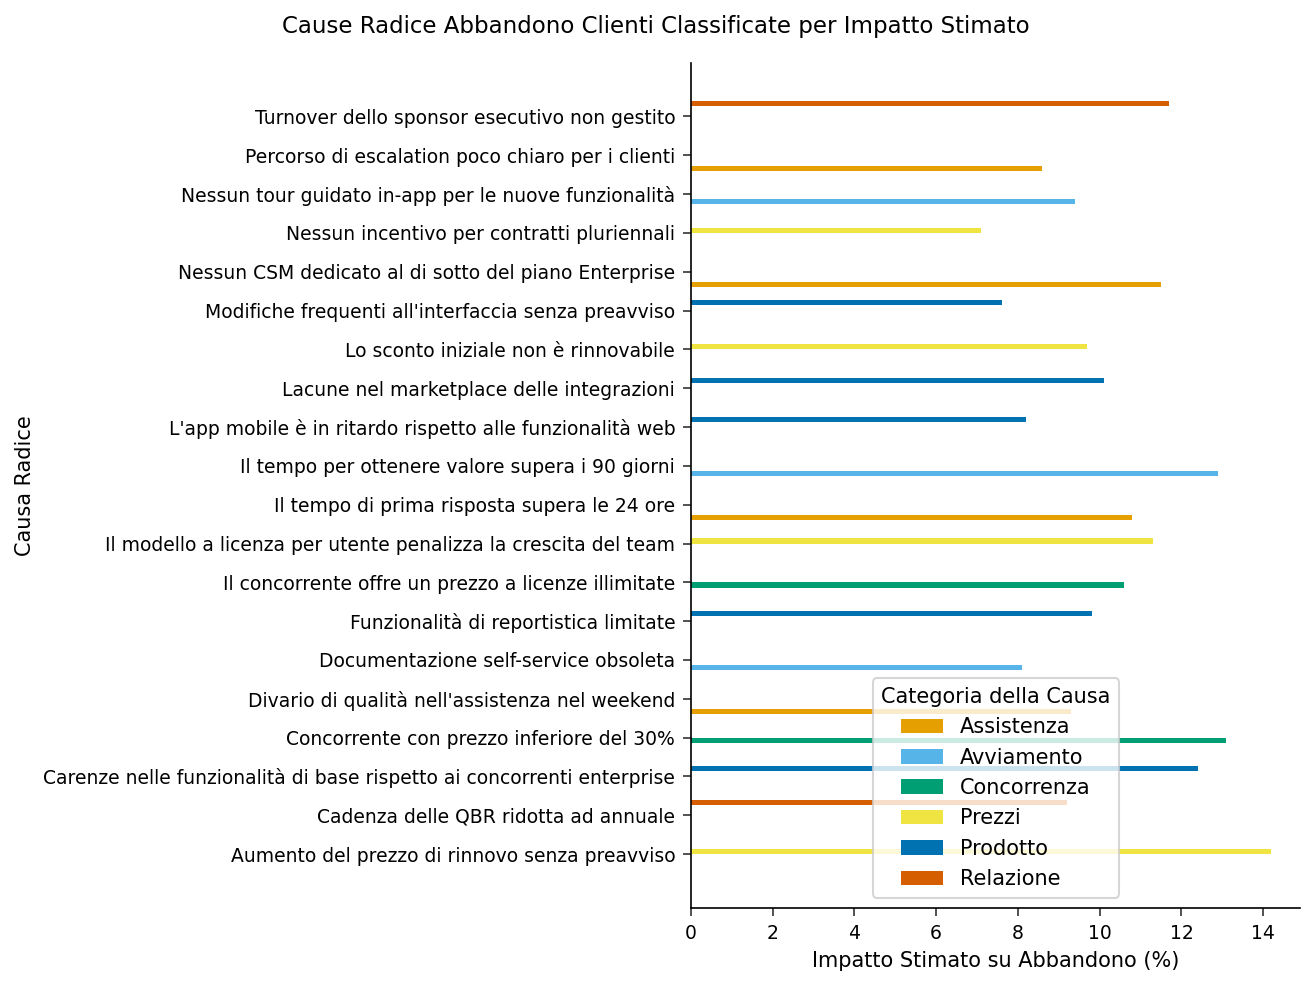

In [3]:
/* --------------------------------------------------------
   Vista Pareto: cause radice individuali classificate per
   impatto stimato sull'abbandono, colorate per categoria.
   Completa il fishbone quantificando quali ossa contano di
   piu'.
   -------------------------------------------------------- */
PROCEDURA ORDINARE DATI=work.churn_rca;
    PER DISCENDENTE churn_impact_pct;
ESEGUIRE;

PROCEDURA SGPLOT DATI=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS label='Impatto Stimato su Abbandono (%)';
    YAXIS label='Causa Radice' discreteorder=data;
    keylegend / title='Categoria della Causa' position=bottom;
    TITOLO 'Cause Radice Abbandono Clienti Classificate per Impatto Stimato';
ESEGUIRE;


---

### Diagramma causa-effetto (Ishikawa)

`PROC FISHBONE` costruisce il diagramma direttamente da `WORK.CHURN_RCA`: ogni `category` distinta diventa un osso principale sulla spina centrale, e i singoli risultati `cause` sono appesi al proprio osso di categoria come sotto-cause. La procedura stampa di seguito la struttura causa-effetto completa — l'effetto in testa, le sei ossa di categoria, e ogni sotto-causa raggruppata sotto il proprio osso — e scrive su disco il grafico fishbone corrispondente. Il grafico Pareto classificato sopra è la vista complementare che quantifica quale di queste ossa porta il maggiore abbandono attribuibile.


In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: diagramma causa-effetto dell'abbandono
   clienti. Il diagramma e' costruito direttamente da
   WORK.CHURN_RCA, quindi le sei categorie di causa e le
   loro cause sono esattamente i risultati analizzati sopra.
   CATEGORY forma le ossa principali; CAUSE si appende come
   sotto-causa a ogni osso.
   -------------------------------------------------------- */
PROCEDURA fishbone DATI=work.churn_rca;
    cause category / subcause=cause;
    effect 'Abbandono Clienti Elevato (18% annuo rispetto a target 8%)';
    TITOLO 'Analisi Causa Radice Abbandono Clienti - Segmento Mid-Market';
    footnote 'Fonti: sondaggi di uscita, interviste al team CS, attribuzione per coorte';
ESEGUIRE;


                      Analisi Causa Radice Abbandono Clienti: Percentuale di Impatto per Categoria                      


                    Analisi Causa Radice Abbandono Clienti - Segmento Mid-Market
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Abbandono Clienti Elevato (18% annuo rispetto a target 8%)
    [CAUSE] Prezzi (top)
      [SUB] Aumento del prezzo di rinnovo senza preavviso
      [SUB] Il modello a licenza per utente penalizza la crescita del team
      [SUB] Lo sconto iniziale non è rinnovabile
      [SUB] Nessun incentivo per contratti pluriennali
    [CAUSE] Concorrenza (top)
      [SUB] Concorrente con prezzo inferiore del 30%
      [SUB] Il concorrente offre un prezzo a licenze illimitate
    [CAUSE] Avviamento (top)
      [SUB] Il tempo per ottenere valore supera i 90 giorni
      [SUB] Nessun tour guidato in-app per le nuove funzionalità
      [SUB] Documentazione self-service obsoleta
    [CAUSE] Prodotto (bottom)
      [SUB] 


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Interpretazione

La struttura causa-effetto e i dati per categoria di `PROC MEANS` indicano alla dirigenza un piccolo numero di azioni ad alto impatto. I due risultati con causa singola più elevati — l'aumento del prezzo di rinnovo di **Prezzi** senza preavviso (14,2) e il risultato di **Concorrenza** secondo cui un rivale vende capacità equivalente a un prezzo inferiore del 30% (13,1) — sono entrambi problemi commerciali piuttosto che di prodotto, il che suggerisce che la trasparenza sui prezzi e il posizionamento competitivo siano le leve più urgenti nel breve termine. Il tempo per ottenere valore di **Avviamento** che supera i 90 giorni (12,9) è il maggior risultato sul lato servizio ed è direttamente collegato alla gestione delle aspettative pre-vendita.

Per volume, **Prodotto** domina il diagramma (5 risultati su 20, 48,1 punti di impatto totali), ma i suoi risultati sono singolarmente più piccoli (media 9,6) rispetto a quelli di **Concorrenza** (media 11,8) o **Prezzi** (media 10,6) — un promemoria che un lungo elenco di lacune di prodotto non è automaticamente la priorità principale. L'osso **Relazione** (turnover dello sponsor esecutivo e cadenza QBR ridotta, 20,9 combinati) rappresenta cambiamenti di processo che il team CS può implementare nel trimestre corrente senza investimenti in prodotto o prezzi, offrendo il percorso più rapido verso un miglioramento misurabile della retention. L'elenco completo classificato nel grafico Pareto permette alla dirigenza di sequenziare gli interventi per impatto stimato piuttosto che per dimensione della categoria.


---

In [5]:
/* --------------------------------------------------------
   Esporta i risultati RCA dell'abbandono per il deck della
   revisione strategica
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
ESEGUIRE;



NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>